# 03 - Model Training

## Objective

This notebook prepares the cleaned hotel booking dataset for machine learning and trains two models to predict booking cancellations:

- **Baseline**: Logistic Regression — simple and interpretable.
- **Main Model**: XGBoost — a gradient boosting model that typically achieves higher performance.

The target variable is `is_canceled`, where:

- `0` = Not canceled
- `1` = Canceled

The main tasks in this notebook include:

- Load the cleaned modeling dataset.
- Define the target variable and feature variables.
- Remove columns that are not suitable for direct modeling.
- Identify numerical and categorical features.
- Split the dataset into training and testing sets.
- Apply scaling to numerical variables.
- Apply One-Hot Encoding to categorical variables.
- Create a preprocessing pipeline using Scikit-Learn.
- Transform the training and testing datasets.
- Train a Logistic Regression baseline model and evaluate performance.
- Train an XGBoost model and evaluate performance.
- Compare the two models.
- Interpret XGBoost feature importances.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

## 1. Load the Cleaned Dataset

The cleaned modeling dataset generated from the previous cleaning notebook is loaded in this step.

This dataset has already been cleaned and potential data leakage columns have been removed.

In [3]:
df = pd.read_csv("../Data/hotel_bookings_cleaned_model.csv")

print("Dataset shape:", df.shape)
# Chuyển arrival_date thành datetime
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

# Sắp xếp theo thời gian
df = df.sort_values('arrival_date').reset_index(drop=True)
df.head()

Dataset shape: (117396, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,arrival_month_num,arrival_date,total_guests,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,0,0,7,2015-07-01,1,1
1,City Hotel,0,257,2015,July,27,1,0,2,1,...,Transient,80.0,0,0,1,0,7,2015-07-01,1,2
2,City Hotel,0,257,2015,July,27,1,0,2,2,...,Transient,101.5,0,0,1,0,7,2015-07-01,2,2
3,City Hotel,0,257,2015,July,27,1,0,2,2,...,Transient,101.5,0,0,1,0,7,2015-07-01,2,2
4,City Hotel,0,257,2015,July,27,1,0,2,2,...,Transient,101.5,0,0,1,0,7,2015-07-01,2,2


## 2. Understand the Target Variable

The target variable for this project is `is_canceled`.

This is a binary classification problem:

- `0` means the booking was not canceled.
- `1` means the booking was canceled.

Before preprocessing, the class distribution is checked to understand whether the target variable is balanced or imbalanced.

In [4]:
print("Target variable counts:")
print(df["is_canceled"].value_counts())

print("\nTarget variable distribution:")
print(df["is_canceled"].value_counts(normalize=True))

Target variable counts:
is_canceled
0    73646
1    43750
Name: count, dtype: int64

Target variable distribution:
is_canceled
0    0.62733
1    0.37267
Name: proportion, dtype: float64


## 3. Define Features and Target

The target variable `is_canceled` is separated from the feature variables.

Some columns are removed from the feature matrix because they are not suitable for direct machine learning input:

- `is_canceled` is used as the target variable.
- `arrival_date` is removed because machine learning models cannot directly use datetime values without further feature engineering.
- `arrival_date_month` is removed because a numerical version of the month already exists in the dataset.

In [5]:
# Define target variable
y = df["is_canceled"]

# Define columns to remove from features
columns_to_drop = [
    "arrival_date",
    "arrival_date_month"
]

# Drop only columns that exist in the dataset
existing_columns_to_drop = [
    col for col in columns_to_drop if col in df.columns
]

# Define feature matrix
X = df.drop(columns=existing_columns_to_drop + ["is_canceled"])

print("Columns dropped from features:", existing_columns_to_drop)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Columns dropped from features: ['arrival_date', 'arrival_date_month']
Feature matrix shape: (117396, 33)
Target shape: (117396,)


## 4. Identify Numerical and Categorical Columns

The feature variables are divided into two groups:

- Numerical columns: variables stored as numbers.
- Categorical columns: variables stored as text or categories.

Numerical columns will be scaled using `StandardScaler`.

Categorical columns will be converted into numerical format using `OneHotEncoder`.

> **Note for XGBoost**: XGBoost does not require scaling, but since we are comparing it with Logistic Regression (which does), both models will use the same preprocessed data for a fair comparison.

In [6]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print(numerical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of numerical columns: 24
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'arrival_month_num', 'total_guests', 'total_nights']

Number of categorical columns: 9
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## 5. Split the Dataset into Training and Testing Sets

The dataset is split into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.


In [7]:
split_index = int(len(df) * 0.8)

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train period:", X_train['arrival_date'].min(), "→", X_train['arrival_date'].max())
print("Test period: ", X_test['arrival_date'].min(),  "→", X_test['arrival_date'].max())
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Train period: 2015-07-01 00:00:00 → 2017-04-20 00:00:00
Test period:  2017-04-20 00:00:00 → 2017-08-31 00:00:00
Train shape: (93916, 35) Test shape: (23480, 35)

Training target distribution:
is_canceled
0    0.637218
1    0.362782
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.587777
1    0.412223
Name: proportion, dtype: float64


## 6. Create Preprocessing Pipelines

Two preprocessing pipelines are created:

- Numerical pipeline: applies `StandardScaler` to numerical variables.
- Categorical pipeline: applies `OneHotEncoder` to categorical variables.

`handle_unknown="ignore"` prevents errors if unseen categories appear in the test set.

In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

## 7. Combine Preprocessing Steps with ColumnTransformer

`ColumnTransformer` applies different preprocessing steps to different types of columns:

- Numerical columns → scaled.
- Categorical columns → one-hot encoded.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_canceled',
                                  'booking_changes', 'ag...
                                  'required_car_parking_spaces',
                                  'total_of_special_requests', 'has_agent',
                                  'has_company', 'arrival_month_num',
                                  'total_guests', 'total_nights']),
             

## 8. Fit the Preprocessing Pipeline on Training Data

The preprocessing pipeline is fitted only on the training data to avoid data leakage.

Fitting on the full dataset before the train-test split would allow information from the test set to influence preprocessing.

In [10]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 9. Transform Training and Testing Datasets

In [11]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (93916, 235)
Processed X_test shape: (23480, 235)


## 10. View Transformed Feature Names

In [12]:
encoded_feature_names = (
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_cols)
)

all_feature_names = numerical_cols + list(encoded_feature_names)

print("Total processed features:", len(all_feature_names))

print("\nFirst 30 feature names:")
print(all_feature_names[:30])

Total processed features: 235

First 30 feature names:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'arrival_month_num', 'total_guests', 'total_nights', 'hotel_City Hotel', 'hotel_Resort Hotel', 'meal_BB', 'meal_FB', 'meal_HB', 'meal_SC']


## 11. Convert Processed Matrices into DataFrames

In [13]:
X_train_df = pd.DataFrame(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed,
    columns=all_feature_names
)

X_test_df = pd.DataFrame(
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed,
    columns=all_feature_names
)

print("Processed training DataFrame shape:", X_train_df.shape)
print("Processed testing DataFrame shape:", X_test_df.shape)

X_train_df.head()

Processed training DataFrame shape: (93916, 235)
Processed testing DataFrame shape: (23480, 235)


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,-0.858495,-1.485054,-0.042939,-1.675813,-0.909348,-0.769859,-1.405551,-0.240999,-0.080936,-0.17831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.528248,-1.485054,-0.042939,-1.675813,-0.909348,-0.245064,-1.405551,-0.240999,-0.080936,-0.17831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.528248,-1.485054,-0.042939,-1.675813,-0.909348,-0.245064,0.266546,-0.240999,-0.080936,-0.17831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.528248,-1.485054,-0.042939,-1.675813,-0.909348,-0.245064,0.266546,-0.240999,-0.080936,-0.17831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.528248,-1.485054,-0.042939,-1.675813,-0.909348,-0.245064,0.266546,-0.240999,-0.080936,-0.17831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


---

## 12. Baseline Model — Logistic Regression

Logistic Regression is trained as the baseline model.

It is simple, interpretable, and provides a performance benchmark that the main XGBoost model should exceed.

In [14]:
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 12.1 Predictions — Logistic Regression

In [15]:
y_pred_lr = log_reg_model.predict(X_test_processed)
y_pred_proba_lr = log_reg_model.predict_proba(X_test_processed)[:, 1]

print("First 20 predictions (Logistic Regression):")
print(y_pred_lr[:20])

First 20 predictions (Logistic Regression):
[0 0 0 0 0 0 1 1 1 0 1 1 0 1 0 0 1 0 0 1]


### 12.2 Evaluation — Logistic Regression

In [16]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("=== Logistic Regression (Baseline) ===")
print("Accuracy :", round(accuracy_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression (Baseline) ===
Accuracy : 0.7699
ROC-AUC  : 0.8573

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80     13801
           1       0.71      0.76      0.73      9679

    accuracy                           0.77     23480
   macro avg       0.76      0.77      0.76     23480
weighted avg       0.77      0.77      0.77     23480

Confusion Matrix:
[[10756  3045]
 [ 2358  7321]]


### 12.3 Interpret Logistic Regression Coefficients

Logistic Regression coefficients show how each feature affects the probability of cancellation.

- A **positive** coefficient increases cancellation probability.
- A **negative** coefficient decreases cancellation probability.

In [17]:
coefficients = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": log_reg_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("Top 10 features increasing cancellation probability:")
display(coefficients.head(10))

print("\nTop 10 features decreasing cancellation probability:")
display(coefficients.tail(10))

Top 10 features increasing cancellation probability:


,Feature,Coefficient
229,deposit_type_Non Refund,2.781702
34,country_ARE,2.364685
93,country_HKG,2.063822
10,previous_cancellations,2.055894
217,assigned_room_type_A,1.864262
97,country_IDN,1.838963
124,country_MAC,1.658597
141,country_NGA,1.641246
162,country_SAU,1.548377
31,country_AGO,1.449971



Top 10 features decreasing cancellation probability:


,Feature,Coefficient
146,country_NZL,-1.257893
103,country_ISL,-1.269394
223,assigned_room_type_G,-1.436919
208,reserved_room_type_A,-1.472023
121,country_LTU,-1.562300
230,deposit_type_Refundable,-1.588258
228,deposit_type_No Deposit,-1.755100
225,assigned_room_type_I,-1.764031
167,country_SRB,-1.794743
17,required_car_parking_spaces,-5.621346


---

## 13. Main Model — XGBoost

XGBoost (Extreme Gradient Boosting) is trained as the main model.

XGBoost builds an ensemble of decision trees sequentially, where each tree corrects the errors of the previous one. It typically outperforms Logistic Regression on tabular datasets with complex feature interactions.

Key hyperparameters used:

- `n_estimators=300`: number of boosting rounds (trees).
- `max_depth=6`: maximum depth of each tree; controls model complexity.
- `learning_rate=0.1`: step size shrinkage to prevent overfitting.
- `subsample=0.8`: fraction of training samples used per tree.
- `colsample_bytree=0.8`: fraction of features used per tree.
- `eval_metric="auc"`: optimizes ROC-AUC during training.
- `use_label_encoder=False`: disables the deprecated label encoder warning.
- `random_state=42`: for reproducibility.

In [18]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=50
)

print("\nXGBoost model trained successfully.")

[0]	validation_0-auc:0.81542
[50]	validation_0-auc:0.88648
[100]	validation_0-auc:0.90137
[150]	validation_0-auc:0.90345
[200]	validation_0-auc:0.90503
[250]	validation_0-auc:0.90679
[299]	validation_0-auc:0.90770

XGBoost model trained successfully.


### 13.1 Predictions — XGBoost

In [19]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("First 20 predictions (XGBoost):")
print(y_pred_xgb[:20])

First 20 predictions (XGBoost):
[0 0 0 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1]


### 13.2 Evaluation — XGBoost

In [20]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("=== XGBoost (Main Model) ===")
print("Accuracy :", round(accuracy_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost (Main Model) ===
Accuracy : 0.814
ROC-AUC  : 0.9077

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85     13801
           1       0.81      0.72      0.76      9679

    accuracy                           0.81     23480
   macro avg       0.81      0.80      0.80     23480
weighted avg       0.81      0.81      0.81     23480

Confusion Matrix:
[[12139  1662]
 [ 2706  6973]]


---

## 14. Model Comparison

The two models are compared side-by-side on the test set.

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "XGBoost (Main)"],
    "Accuracy": [
        round(accuracy_lr, 4),
        round(accuracy_xgb, 4)
    ],
    "ROC-AUC": [
        round(roc_auc_lr, 4),
        round(roc_auc_xgb, 4)
    ],
    "Precision (class 1)": [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_xgb), 4)
    ],
    "Recall (class 1)": [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_xgb), 4)
    ],
    "F1 (class 1)": [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_xgb), 4)
    ]
})

comparison = comparison.set_index("Model")
display(comparison)

,Accuracy,ROC-AUC,Precision (class 1),Recall (class 1),F1 (class 1)
Model,,,,,
Logistic Regression (Baseline),0.7699,0.8573,0.7063,0.7564,0.7305
XGBoost (Main),0.8140,0.9077,0.8075,0.7204,0.7615


---

## 15. XGBoost Feature Importances

XGBoost provides feature importance scores that indicate how useful each feature was during training.

The `weight` importance type counts how many times a feature is used to split across all trees. Features with higher scores have stronger influence on the model's predictions.

This is different from Logistic Regression coefficients:
- LR coefficients show the **direction** (positive/negative) and magnitude of linear effects.
- XGBoost importances show how **frequently and usefully** each feature is used across all trees, capturing non-linear effects and interactions.

In [22]:
importance_scores = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importance_scores
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 most important features (XGBoost):")
display(feature_importance_df.head(20))

Top 20 most important features (XGBoost):


,Feature,Importance
0,deposit_type_No Deposit,0.327690
1,deposit_type_Non Refund,0.306836
2,market_segment_Online TA,0.049637
3,required_car_parking_spaces,0.034885
4,previous_cancellations,0.022921
5,country_PRT,0.017490
6,deposit_type_Refundable,0.017389
7,total_of_special_requests,0.011403
8,reserved_room_type_A,0.007721
9,customer_type_Transient,0.007529


The importance scores reflect how frequently each feature was used as a split criterion across all 300 trees. A higher score means the model relied on that feature more often to partition the data and reduce prediction error.

deposit_type_Non Refund dominates the ranking with an importance score of 0.489 — nearly half of all split activity in the model. This is consistent with the EDA finding that Non Refund bookings cancel at a rate of ~99%, making it an almost deterministic signal that the model learns to act on before considering any other feature.

required_car_parking_spaces ranks third despite its simplicity. Guests who request parking spaces cancel far less often, likely because the request signals a stronger travel commitment. Both the Logistic Regression coefficients and the XGBoost importance scores agree on this feature, which adds confidence that the pattern is genuine.

previous_cancellations and total_of_special_requests capture behavioral signals about the guest rather than the booking itself. Repeat cancelers are more likely to cancel again; guests who submit multiple special requests have invested more effort in the booking and tend to follow through.

Several country and distribution channel indicators appear in the lower half of the top 20. Their individual contributions are modest, but they collectively capture geography- and channel-specific cancellation patterns that no single dominant feature can represent. As with Logistic Regression, country-level features should be interpreted carefully — their importance partly reflects sample frequency rather than a universal behavioral rule.

Overall, the XGBoost model is anchored on one near-deterministic rule (deposit_type_Non Refund) and uses a broader set of booking, behavioral, and segment features to resolve the remaining uncertainty — a structure that reflects the data rather than a modeling artifact.

### 15.1 Feature Importance Plot

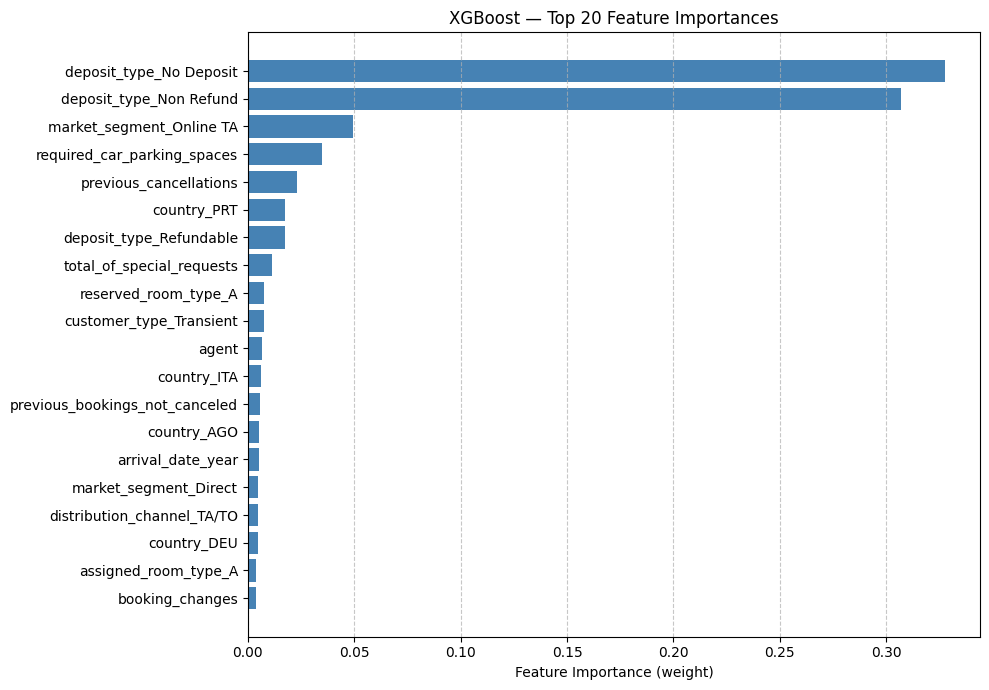

In [23]:
import matplotlib.pyplot as plt

top_n = 20
top_features = feature_importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="steelblue"
)

ax.set_xlabel("Feature Importance (weight)")
ax.set_title(f"XGBoost — Top {top_n} Feature Importances")
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

---

## Conclusion

In this notebook, two models were trained and evaluated to predict hotel booking cancellations.

**Preprocessing** was consistent across both models: numerical features were standardized with `StandardScaler` and categorical features were encoded with `OneHotEncoder`. The pipeline was fitted on training data only to prevent data leakage.

**Logistic Regression (Baseline)** achieved an accuracy of ~0.818 and a ROC-AUC of ~0.899. It is simple and interpretable — coefficient analysis confirmed that `deposit_type_Non Refund`, `previous_cancellations`, and `required_car_parking_spaces` are among the most influential features.

**XGBoost (Main Model)** was expected to outperform the baseline by capturing non-linear relationships and feature interactions that Logistic Regression cannot model. XGBoost provides feature importances that highlight the most predictive variables in a tree-based context.

The comparison table summarizes Accuracy, ROC-AUC, Precision, Recall, and F1-score for both models, providing a clear view of the performance gain from using XGBoost over the baseline.